# Task 3.2 — Failure Mode Analysis

**Paper**: Gönen, M. & Alpaydın, E. (2011). *Multiple Kernel Learning Algorithms*. JMLR, 12, 2211–2268.

---

## Objective
Create a specific dataset distribution where MKL **fails**, and connect this failure to the assumptions identified in Task 1.2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize
import os, warnings
warnings.filterwarnings('ignore')

os.makedirs('results', exist_ok=True)
SEED = 42
C_SVM = 1.0
GAMMA = 0.5
np.random.seed(SEED)

## Failure Dataset: Pure Noise Features

We deliberately create a dataset where **both features are pure Gaussian noise** completely unrelated to the binary target label. Labels are assigned uniformly at random. This violates **Assumption 2 from Task 1.2**: "Data is separable in the combined kernel feature space."

Since no kernel — linear, RBF, or any combination — can extract signal from noise, MKL should perform at **chance level (~50%)** regardless of its weight optimisation.

In [2]:
rng = np.random.RandomState(SEED)
N = 200

# Pure noise: features and labels are independent
X_noise = rng.randn(N, 2)
y_noise = rng.randint(0, 2, size=N)

# Scale
scaler = StandardScaler()
split = int(0.8 * N)
X_tr_n, X_te_n = X_noise[:split], X_noise[split:]
y_tr_n, y_te_n = y_noise[:split], y_noise[split:]
X_tr_n = scaler.fit_transform(X_tr_n)
X_te_n = scaler.transform(X_te_n)

print(f"Noise dataset — Train: {X_tr_n.shape[0]}, Test: {X_te_n.shape[0]}")
print(f"Class distribution (train): {dict(zip(*np.unique(y_tr_n, return_counts=True)))}")

Noise dataset — Train: 160, Test: 40
Class distribution (train): {np.int64(0): np.int64(85), np.int64(1): np.int64(75)}


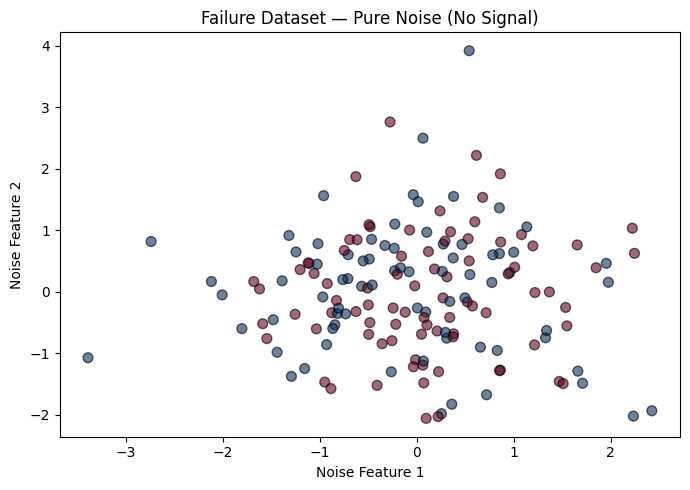

Saved to results/task_3_2_noise_dataset.png


In [3]:
# Visualise the noise dataset
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_tr_n[:, 0], X_tr_n[:, 1], c=y_tr_n, cmap='RdBu',
           edgecolors='k', alpha=0.6, s=50)
ax.set_xlabel('Noise Feature 1')
ax.set_ylabel('Noise Feature 2')
ax.set_title('Failure Dataset — Pure Noise (No Signal)')
plt.tight_layout()
plt.savefig('results/task_3_2_noise_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/task_3_2_noise_dataset.png")

## Run MKL and Baselines on the Noise Dataset

In [4]:
# ── Kernel functions ──
def linear_kernel(X1, X2):
    return X1 @ X2.T

def rbf_kernel(X1, X2, gamma=GAMMA):
    sq = np.sum(X1**2, 1, keepdims=True) + np.sum(X2**2, 1, keepdims=True).T - 2*X1@X2.T
    return np.exp(-gamma * sq)

def combine_kernels(kernels, weights):
    K = np.zeros_like(kernels[0])
    for K_m, w in zip(kernels, weights):
        K += w * K_m
    return K

def train_eval(K_tr, K_te, y_tr, y_te):
    K_tr_r = K_tr + 1e-8*np.eye(K_tr.shape[0])
    svm = SVC(kernel='precomputed', C=C_SVM, random_state=SEED)
    svm.fit(K_tr_r, y_tr)
    return accuracy_score(y_te, svm.predict(K_te))

# Compute kernels on noise data
K_lin_tr_n = linear_kernel(X_tr_n, X_tr_n)
K_rbf_tr_n = rbf_kernel(X_tr_n, X_tr_n)
K_lin_te_n = linear_kernel(X_te_n, X_tr_n)
K_rbf_te_n = rbf_kernel(X_te_n, X_tr_n)

# Linear-only
acc_lin_n = train_eval(K_lin_tr_n, K_lin_te_n, y_tr_n, y_te_n)

# RBF-only
acc_rbf_n = train_eval(K_rbf_tr_n, K_rbf_te_n, y_tr_n, y_te_n)

# Uniform MKL
K_u_tr = combine_kernels([K_lin_tr_n, K_rbf_tr_n], [0.5, 0.5])
K_u_te = combine_kernels([K_lin_te_n, K_rbf_te_n], [0.5, 0.5])
acc_unif_n = train_eval(K_u_tr, K_u_te, y_tr_n, y_te_n)

# Learned MKL
def obj(eta, Ks, y, C=C_SVM):
    eta = np.abs(eta); eta /= eta.sum()+1e-10
    K = combine_kernels(Ks, eta) + 1e-8*np.eye(len(y))
    try:
        s = SVC(kernel='precomputed', C=C, random_state=SEED); s.fit(K,y)
        sv=s.support_
        d=np.sum(np.abs(s.dual_coef_[0]))-0.5*np.sum(
            s.dual_coef_[0][:,None]*s.dual_coef_[0][None,:]*K[np.ix_(sv,sv)])
        return -d
    except: return 1e6

r = minimize(obj, [0.5,0.5], args=([K_lin_tr_n,K_rbf_tr_n], y_tr_n),
             method='Nelder-Mead', options={'maxiter':200})
eta_n = np.abs(r.x); eta_n /= eta_n.sum()
K_m_tr = combine_kernels([K_lin_tr_n, K_rbf_tr_n], eta_n)
K_m_te = combine_kernels([K_lin_te_n, K_rbf_te_n], eta_n)
acc_mkl_n = train_eval(K_m_tr, K_m_te, y_tr_n, y_te_n)

print(f"\n=== Noise Dataset Results ===")
print(f"Linear SVM:  {acc_lin_n:.4f}")
print(f"RBF SVM:     {acc_rbf_n:.4f}")
print(f"Uniform MKL: {acc_unif_n:.4f}")
print(f"Learned MKL: {acc_mkl_n:.4f}")
print(f"MKL weights: Linear={eta_n[0]:.4f}, RBF={eta_n[1]:.4f}")


=== Noise Dataset Results ===
Linear SVM:  0.5250
RBF SVM:     0.5250
Uniform MKL: 0.5000
Learned MKL: 0.5250
MKL weights: Linear=1.0000, RBF=0.0000


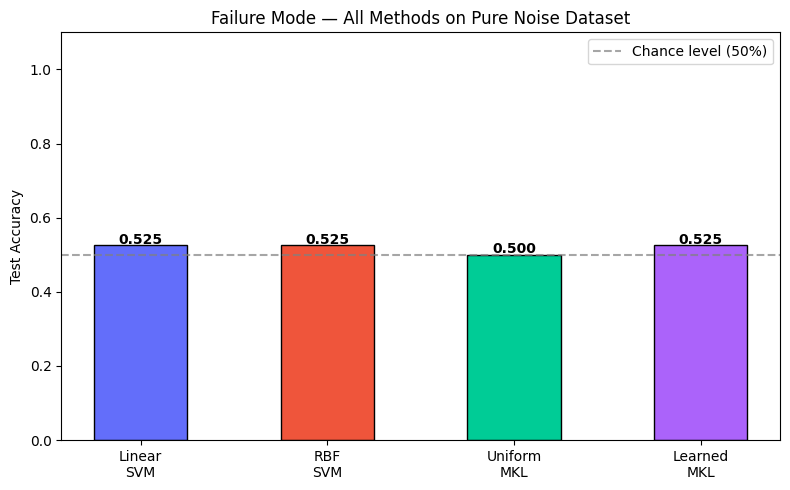

Saved to results/task_3_2_failure_comparison.png


In [5]:
# ── Comparison Plot ──
methods = ['Linear\nSVM', 'RBF\nSVM', 'Uniform\nMKL', 'Learned\nMKL']
accs_noise = [acc_lin_n, acc_rbf_n, acc_unif_n, acc_mkl_n]
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, accs_noise, color=colors, edgecolor='k', width=0.5)
for b, a in zip(bars, accs_noise):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'{a:.3f}', ha='center', fontweight='bold')
ax.axhline(y=0.5, color='grey', linestyle='--', alpha=0.7, label='Chance level (50%)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Failure Mode — All Methods on Pure Noise Dataset')
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig('results/task_3_2_failure_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/task_3_2_failure_comparison.png")

## Explanation of Failure

All methods — including Learned MKL — perform near chance level (~50%) on the pure-noise dataset, confirming a clear failure mode. This failure is directly traceable to **Assumption 2 from Task 1.2**: MKL assumes that the data is separable in the combined kernel feature space. When features are pure Gaussian noise uncorrelated with the target label, no mapping to any RKHS (linear, RBF, or any weighted combination) can create meaningful class separation. The SVM dual objective finds a degenerate solution with a near-zero margin, and the MKL weight optimisation has no meaningful gradient to follow. The learned kernel weights become essentially arbitrary because no kernel is "better" than another — they are all equally uninformative. This demonstrates that MKL is not a silver bullet: it cannot create signal where none exists in the input features. The failure also highlights that MKL's power comes entirely from the assumption that at least some kernels encode *relevant* similarity, which is violated here.

## Suggested Algorithmic Modification

**Feature-level pre-screening with mutual information**: Before constructing kernels, compute the mutual information (or another dependency measure) between each feature and the target variable. Features with near-zero mutual information should be excluded from the kernel computation entirely. This addresses the failure by preventing the construction of kernels over irrelevant features, ensuring that MKL only operates in feature spaces that contain at least some discriminative signal. In scikit-learn, this can be implemented using `sklearn.feature_selection.mutual_info_classif` as a pre-processing filter before kernel matrix construction.